# 4.5 Los tres pilares del desarrollo de modelos

Un modelo de aprendizaje profundo que funciona descansa sobre tres pilares:

1. **Los datos de entrenamiento**: su calidad, diversidad, balance entre clases y nivel de ruido.
2. **La arquitectura**: la familia de funciones que la red puede representar, y cuántos parámetros gasta en hacerlo.
3. **La estrategia de entrenamiento**: la función de pérdida, el optimizador, la tasa de aprendizaje, el tamaño de lote, la regla de parada.

La mayoría de las fallas de un modelo se remontan a exactamente uno de estos pilares, y cada pilar falla con una firma reconocible. Este cuaderno es un laboratorio práctico: mantenemos fija una tarea de clasificación y rompemos cada pilar a propósito, para que usted aprenda a leer las firmas antes de encontrarlas en los datos de su proyecto.

El laboratorio usa perceptrones multicapa pequeños sobre una tabla de litologías sintética. Cada experimento corre en segundos en la CPU de una computadora portátil. Puede aumentar los conteos de muestras y las épocas en su propia máquina; las lecciones no cambian.

🖥️ [**Diapositivas — Sesión 24 — laboratorio I (mié 25 nov)**](https://geo-smart.github.io/mlgeo-book/slides/2026/lec24_three_pillars_lab_I.html)

🖥️ [**Diapositivas — Sesión 25 — laboratorio II (lun 30 nov)**](https://geo-smart.github.io/mlgeo-book/slides/2026/lec25_three_pillars_lab_II.html)

## 1. Una tarea, un modelo pequeño

La tarea para todo el laboratorio: clasificar muestras de roca en tres clases litológicas (granito, basalto, andesita) a partir de 9 características geoquímicas y físicas (óxidos de elementos mayores en wt%, densidad en g/cm$^3$, susceptibilidad magnética en unidades SI). Los datos provienen de `mlgeo_synth.geochem_table`, un generador que planta correlaciones realistas entre los óxidos a través de un índice de diferenciación latente. Como el generador es nuestro, controlamos la cantidad exacta de ruido en las etiquetas, de desbalance de clases y de ruido de sensores — las perillas que los datos reales nunca nos dan.

Un ajuste hace realista el laboratorio: las tablas crudas del generador son casi perfectamente separables, cosa que ningún instrumento de campo entrega. Por eso, cada conjunto de datos de este laboratorio lleva un piso fijo de ruido de medición de una desviación estándar por característica, aplicado por igual a entrenamiento, validación y prueba. Los experimentos de corrupción de la sección 3 agregan defectos específicos sobre ese piso.

### 1.1 Conjuntos de entrenamiento, validación y prueba

Antes de cualquier experimento, los datos se dividen en tres:

* **Conjunto de entrenamiento**: se usa para ajustar el modelo. Debe ser la porción más grande, típicamente el 60-80 % de los datos, y tan diverso y balanceado como el problema lo permita.
* **Conjunto de validación**: se usa durante el entrenamiento para ajustar hiperparámetros y detectar el sobreajuste. Da una estimación del desempeño sobre datos no vistos mientras las decisiones todavía se están tomando. Típicamente el 10-20 %.
* **Conjunto de prueba**: se usa una sola vez, al final, para reportar la generalización. Debe permanecer completamente separado de cada decisión tomada durante el desarrollo del modelo. Si información del conjunto de prueba influye en el entrenamiento o en la selección del modelo, el desempeño reportado queda inflado. Esta falla se llama **fuga de datos** (*data leakage*), y reaparece en la sección 5.

Un detalle importa para este laboratorio: nuestro **conjunto de prueba siempre está limpio** (sin ruido en las etiquetas, sin defectos más allá del piso compartido de ruido de medición), incluso cuando corrompemos a propósito los datos de entrenamiento. Así es como medimos lo que cuesta la corrupción.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, recall_score

import mlgeo_synth

# Device-agnostic setup. The models in this lab are tiny (a few thousand
# parameters), and for models this small the CPU is faster than an
# accelerator because kernel-launch overhead dominates. We detect the
# accelerator to show the pattern, then deliberately train on CPU.
detected = torch.device("cuda" if torch.cuda.is_available()
                        else "mps" if torch.backends.mps.is_available()
                        else "cpu")
device = torch.device("cpu")
print(f"accelerator detected: {detected}; using: {device}")

torch.manual_seed(0)
np.random.seed(0)

accelerator detected: mps; using: cpu


In [2]:
df = mlgeo_synth.geochem_table(n=3000, label_noise=0.0, seed=0)
print(df.shape)
df.head()

(3000, 10)


,SIO2,AL2O3,FEO,MGO,CAO,NA2O,K2O,density_g_cm3,mag_susc_si,label
0,48.271072,14.550932,9.584487,7.786032,11.408379,2.258560,0.812292,2.964359,0.001658,basalt
1,72.178440,14.659499,2.189115,1.033966,2.353944,4.054576,4.720737,2.667887,0.000087,granite
2,73.667158,13.452573,1.191274,0.140795,1.781264,4.588104,5.456854,2.651066,0.000108,granite
3,69.915112,14.344166,4.565303,2.014665,2.891233,3.588710,2.962119,2.647545,0.000129,granite
4,50.691400,15.028301,7.642222,6.779043,10.832978,2.687062,0.742804,3.009791,0.001025,basalt


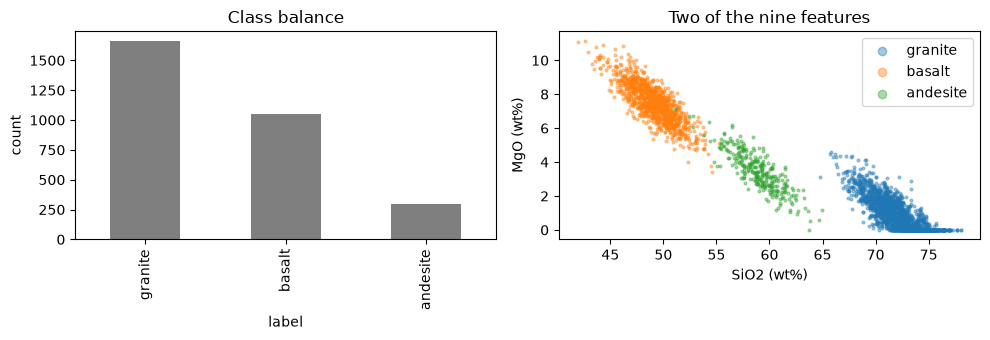

In [3]:
CLASSES = ["granite", "basalt", "andesite"]
FEATURES = [c for c in df.columns if c != "label"]

fig, ax = plt.subplots(1, 2, figsize=(10, 3.5))
df["label"].value_counts().loc[CLASSES].plot.bar(ax=ax[0], color="tab:gray")
ax[0].set_ylabel("count"); ax[0].set_title("Class balance")
for c in CLASSES:
    sub = df[df["label"] == c]
    ax[1].scatter(sub["SIO2"], sub["MGO"], s=4, alpha=0.4, label=c)
ax[1].set_xlabel("SiO2 (wt%)"); ax[1].set_ylabel("MgO (wt%)")
ax[1].set_title("Two of the nine features"); ax[1].legend(markerscale=3)
plt.tight_layout()

Las clases están desbalanceadas por construcción (la andesita es rara) y se solapan en el espacio de características. Ambas propiedades son típicas de los problemas de clasificación geoquímica.

### 1.2 Ayudantes del laboratorio

Tres piezas de código cargan con todo el laboratorio: una función de datos con perillas de corrupción, un MLP configurable y un bucle de entrenamiento que registra curvas de aprendizaje. Léalas una vez, con cuidado; cada experimento de abajo son unas pocas líneas que las llaman.

In [4]:
def table_to_xy(frame):
    X = frame[FEATURES].to_numpy(dtype=np.float32)
    y = frame["label"].map({c: i for i, c in enumerate(CLASSES)}).to_numpy()
    return X, y.astype(np.int64)


def make_data(n_train=3000, label_noise=0.0, minority_keep=1.0,
              feature_noise=0.0, base_noise=1.0, relabel=None,
              hetero_sigma=None, seed=0):
    '''Train/val splits with optional corruption; test set always clean.

    label_noise   : fraction of flipped labels in train+val (uniform flips)
    minority_keep : fraction of andesite (minority) samples kept in train+val
    feature_noise : std of EXTRA Gaussian noise added to standardized features
                    (sensor degradation, in units of one feature std)
    base_noise    : the shared measurement-noise floor on all splits
    relabel       : optional function frame -> frame applied after generation,
                    for structured label errors (Section 3.1)
    hetero_sigma  : optional tuple of noise levels; each TRAINING sample draws
                    its noise floor from these instead of base_noise, and the
                    per-sample sigma comes back as a 7th element (Section 3.3)
    '''
    frame = mlgeo_synth.geochem_table(n=n_train, label_noise=label_noise, seed=seed)
    if relabel is not None:
        frame = relabel(frame)
    if minority_keep < 1.0:
        minority = frame[frame["label"] == "andesite"]
        drop = minority.sample(frac=1.0 - minority_keep, random_state=seed).index
        frame = frame.drop(index=drop)
    X, y = table_to_xy(frame)
    Xtr, Xva, ytr, yva = train_test_split(X, y, test_size=0.25,
                                          random_state=seed, stratify=y)
    # fixed clean test set, drawn from the same generator with a held seed
    Xte, yte = table_to_xy(mlgeo_synth.geochem_table(n=1500, label_noise=0.0, seed=987))
    scaler = StandardScaler().fit(Xtr)          # fit on train only
    Xtr, Xva, Xte = (scaler.transform(a) for a in (Xtr, Xva, Xte))
    rngs = [np.random.default_rng(1000 * seed + k) for k in range(3)]
    # measurement-noise floor on every split; extra sensor noise on top
    if hetero_sigma is None:
        Xtr = Xtr + rngs[0].normal(0, 1, Xtr.shape) * np.hypot(base_noise, feature_noise)
    else:                      # per-sample noise floor on the training split
        sigma_tr = rngs[0].choice(hetero_sigma, size=len(Xtr)).astype(np.float32)
        Xtr = Xtr + rngs[0].normal(0, 1, Xtr.shape) * sigma_tr[:, None]
    Xva = Xva + rngs[1].normal(0, 1, Xva.shape) * np.hypot(base_noise, feature_noise)
    Xte = Xte + rngs[2].normal(0, 1, Xte.shape) * base_noise
    t = lambda a: torch.as_tensor(np.ascontiguousarray(a), dtype=torch.float32)
    out = (t(Xtr), torch.as_tensor(ytr), t(Xva), torch.as_tensor(yva),
           t(Xte), torch.as_tensor(yte))
    if hetero_sigma is not None:
        out = out + (torch.as_tensor(sigma_tr),)
    return out


class MLP(nn.Module):
    def __init__(self, width=32, depth=2, dropout=0.0, n_in=9, n_out=3):
        super().__init__()
        layers, d = [], n_in
        for _ in range(depth):
            layers += [nn.Linear(d, width), nn.ReLU()]
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            d = width
        layers.append(nn.Linear(d, n_out))   # raw logits; softmax lives in the loss
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


def count_params(model):
    return sum(p.numel() for p in model.parameters())

In [5]:
loss_fn = nn.CrossEntropyLoss()


def accuracy(model, X, y):
    model.eval()
    with torch.no_grad():
        return (model(X.to(device)).argmax(1).cpu() == y).float().mean().item()


def train_model(model, data, epochs=25, lr=1e-3, batch_size=256,
                weight_decay=0.0, optimizer="adam", scheduler=None, seed=0):
    '''Minibatch training; returns a history dict of per-epoch curves.'''
    Xtr, ytr, Xva, yva, Xte, yte = data
    model.to(device)
    opt_cls = {"adam": torch.optim.Adam, "sgd": torch.optim.SGD}[optimizer]
    opt = opt_cls(model.parameters(), lr=lr, weight_decay=weight_decay)
    sched = scheduler(opt) if scheduler is not None else None
    n = len(Xtr)
    hist = {k: [] for k in ["train_loss", "val_loss", "train_acc", "val_acc", "lr"]}
    g = torch.Generator().manual_seed(seed)
    for _ in range(epochs):
        model.train()
        for i in range(0, n, batch_size):
            idx = torch.randperm(n, generator=g)[:batch_size] if batch_size < n else slice(None)
            opt.zero_grad()
            loss = loss_fn(model(Xtr[idx].to(device)), ytr[idx].to(device))
            loss.backward()
            opt.step()
        model.eval()
        with torch.no_grad():
            hist["train_loss"].append(loss_fn(model(Xtr.to(device)), ytr.to(device)).item())
            hist["val_loss"].append(loss_fn(model(Xva.to(device)), yva.to(device)).item())
        hist["train_acc"].append(accuracy(model, Xtr, ytr))
        hist["val_acc"].append(accuracy(model, Xva, yva))
        hist["lr"].append(opt.param_groups[0]["lr"])
        if sched is not None:
            sched.step()
    return hist


def plot_history(hist, ax=None, title="", logy=False):
    '''Train/validation loss curves for one run.'''
    if ax is None:
        _, ax = plt.subplots(figsize=(5, 3))
    ax.plot(hist["train_loss"], label="train")
    ax.plot(hist["val_loss"], label="validation")
    if logy:
        ax.set_yscale("log")
    ax.set_xlabel("epoch"); ax.set_ylabel("cross-entropy loss")
    ax.set_title(title); ax.legend(); ax.grid(alpha=0.3)
    return ax

Una nota sobre el bucle de entrenamiento: muestrea un minilote aleatorio fresco en cada paso (descenso de gradiente estocástico por minilotes, sección 2.4) y registra la pérdida de entrenamiento y de validación una vez por época, evaluada en modo `eval()` sobre las divisiones completas. Esas dos curvas por corrida son el instrumento de diagnóstico de todo el laboratorio.

## 2. Qué minimiza el entrenamiento

Antes de los experimentos, el vocabulario. Una **función de pérdida** mide qué tan lejos están las predicciones del modelo de las etiquetas. Proporciona el número único que el descenso de gradiente empuja cuesta abajo, así que su elección moldea todo lo que la red aprende. Las funciones de pérdida $\mathcal{L}(\mathbf{y}, \mathbf{\hat{y}}, \mathbf{w})$ cuantifican los residuos entre las etiquetas verdaderas $\mathbf{y}$ y las predicciones $\mathbf{\hat{y}}$, y deben ser diferenciables con respecto a los parámetros del modelo $\mathbf{w}$.

### 2.1 Pérdidas para regresión

* El **error cuadrático medio** penaliza los errores grandes cuadráticamente. Es la elección natural cuando los errores son casi gaussianos:

  $\mathrm{MSE} = \frac{1}{m} \sum_{i=1}^m \left( \hat{y}_i - y_i \right)^2$

* El **error absoluto medio** penaliza menos los errores grandes, lo que conviene a distribuciones de error de colas pesadas. Su gradiente tiene magnitud constante, lo que puede frenar la convergencia cerca del mínimo; los optimizadores adaptativos como Adam lo mitigan:

  $\mathrm{MAE} = \frac{1}{m} \sum_{i=1}^m |\hat{y}_i - y_i|$

* La **pérdida de Huber** cambia entre las dos: cuadrática para errores menores que un umbral $\delta$ (gradientes suaves cerca del mínimo), lineal más allá (los valores atípicos no dominan).

### 2.2 Pérdidas para clasificación

Los clasificadores binarios producen una probabilidad a través de la **sigmoide logística** $\sigma(x) = 1/(1 + e^{-x})$ y entrenan con la **entropía cruzada binaria**:

$\mathcal{L}(\mathbf{w}) = - \frac{1}{m} \sum_{i=1}^m \left[ y_i \log \hat{p}_i + (1 - y_i) \log(1 - \hat{p}_i) \right]$

Para $K$ clases, la red produce un puntaje $s_k$ por clase y la **softmax** convierte los puntajes en probabilidades:

$\hat{p}_k = \frac{\exp(s_k)}{\sum_{j=1}^K \exp(s_j)}$

con la **entropía cruzada** multiclase como pérdida. `nn.CrossEntropyLoss` de PyTorch aplica la softmax internamente, y por eso nuestro MLP produce logits crudos.

### 2.3 Pérdidas conscientes de las geociencias

Las pérdidas estándar pasan por alto objetivos que importan en nuestro campo. Como cualquier función diferenciable de las predicciones puede ser un término de pérdida, podemos codificar esos objetivos directamente:

* **Pesos de clase para eventos raros.** Los sismos, los deslizamientos de tierra y las señales de caída de rocas son clases raras; pesar más sus errores (`nn.CrossEntropyLoss(weight=...)`) evita que el optimizador las ignore. La sección 3.2 muestra por qué importa.
* **Similitud de formas de onda.** Una red que reconstruye sismogramas debería coincidir ondulación por ondulación. Agregar un término de coeficiente de correlación premia el alineamiento de fase que el MSE apenas ve:

  $\mathcal{L}(\mathbf{\hat{u}}, \mathbf{u}) = \mathrm{MSE}(\mathbf{\hat{u}}, \mathbf{u}) + \lambda \left(1 - \mathrm{CC}(\mathbf{\hat{u}}, \mathbf{u})\right)$

* **Restricciones físicas.** Cuando la salida es un campo físico, un término de pérdida puede penalizar las violaciones de una ecuación de gobierno (conservación de la masa, el residuo de una ecuación de calor). Esta es la base de las redes neuronales informadas por la física, cuaderno 4.7.
* **Pérdidas conscientes de la incertidumbre.** Los pronósticos probabilísticos entrenan con la log-verosimilitud negativa, que penaliza tanto el exceso como la falta de confianza.

### 2.4 El descenso de gradiente y la tasa de aprendizaje

El entrenamiento actualiza los parámetros en la dirección que reduce la pérdida:

$w_j^{(k+1)} = w_j^{(k)} - \alpha \frac{\partial \mathcal{L}}{\partial w_j}$

donde $\alpha$ es la **tasa de aprendizaje**, el hiperparámetro de mayores consecuencias en este cuaderno.

| ![Gradient descent on a convex loss](../img/GD_cartoon.jpeg) | ![Gradient descent with local minima](../img/GD_non_global.png) |
|---|---|
| Descenso de gradiente sobre una pérdida convexa y bien comportada. | Una pérdida mal comportada, con mínimos locales. |

| ![Learning rate too small](../img/GD_AlphaTooSmall.png) | ![Learning rate too large](../img/GD_AlphaTooLarge.png) |
|---|---|
| $\alpha$ demasiado pequeña: la convergencia avanza a paso de tortuga. | $\alpha$ demasiado grande: los pasos se pasan del mínimo. |

Tres variantes difieren en cuántos datos ve cada actualización:

* El **descenso de gradiente por lotes** usa el conjunto de entrenamiento completo por paso: gradientes exactos, pasos costosos.
* El **descenso de gradiente estocástico (SGD)** usa una muestra por paso: actualizaciones baratas y ruidosas, sensibles al escalado de las características.
* El **descenso de gradiente por minilotes** usa un subconjunto aleatorio pequeño por paso. Es el estándar en aprendizaje profundo, y lo que hace nuestro `train_model`. El tamaño de lote intercambia ruido del gradiente por costo por paso; la sección 5.2 mide el efecto.

Los optimizadores adaptativos (Adam, RMSProp) reescalan el paso de cada parámetro usando estadísticas móviles del gradiente. Adam es el valor por defecto en este curso.

### 2.5 Sesgo, varianza, subajuste, sobreajuste

El error de generalización se descompone en tres partes:

* **Sesgo**: error por supuestos de modelo equivocados (ajustar una recta a una curva). El sesgo alto se manifiesta como pérdida alta sobre los propios datos de entrenamiento.
* **Varianza**: error por sensibilidad excesiva a las muestras de entrenamiento particulares. La varianza alta se manifiesta como una brecha entre la pérdida de entrenamiento y la de validación.
* **Error irreducible**: ruido en los datos. Ningún modelo lo elimina; solo mejores datos lo hacen (arreglar sensores, quitar valores atípicos — Pilar 1).

**Subajuste** = sesgo alto: las pérdidas de entrenamiento y validación se estancan ambas en un valor alto. Remedios: un modelo más grande, mejores características, menos regularización.

**Sobreajuste** = varianza alta: la pérdida de entrenamiento sigue cayendo mientras la de validación se estanca y luego sube. El modelo empezó a memorizar el ruido. Remedios: más datos, un modelo más pequeño, regularización, parada temprana (*early stopping*).

Una regla que vale la pena memorizar: *usted no sabe si puede sobreajustar hasta que lo logra*. Haga crecer el modelo hasta que sobreajuste, y luego recorte o regularice. Ambas firmas aparecen en curvas reales en la sección 5.

### 2.6 Regularización

La regularización restringe un modelo flexible para que se comporte de manera más simple:

* **Penalización L2 (ridge)**: agregue $\lambda \frac{1}{2} \lVert \mathbf{w} \rVert_2^2$ a la pérdida, encogiendo todos los pesos. En los optimizadores de PyTorch es el argumento `weight_decay`.
* **Penalización L1 (lasso)**: agregue $\lambda \lVert \mathbf{w} \rVert_1$, que lleva los pesos poco importantes a exactamente cero — una forma de selección de características.
* **Red elástica (*elastic net*)**: una combinación ponderada de ambas.
* ***Dropout*** (apagado aleatorio de neuronas): poner en cero aleatoriamente una fracción de las activaciones durante el entrenamiento, para que ninguna unidad pueda depender de socias específicas. Se usa en el cuaderno 4.2 y está disponible como perilla en nuestro `MLP`.
* **Parada temprana (*early stopping*)**: detener el entrenamiento cuando la pérdida de validación deja de mejorar (sección 5.3).
* **Aumento de datos (*data augmentation*)**: agrandar y diversificar el conjunto de entrenamiento con copias transformadas (desplazamientos, ruido agregado). Regulariza a través del pilar de los datos en lugar del modelo.

## 3. Pilar 1 — Curaduría de los datos de entrenamiento

La calidad del modelo empieza en los datos, y ninguna arquitectura ni optimizador rescata un conjunto de entrenamiento corrompido. Como nuestro generador controla la corrupción con exactitud, podemos medir lo que cuesta cada defecto. En todos los experimentos el **conjunto de prueba permanece limpio**, así que las curvas aíslan el efecto de la calidad de los datos de entrenamiento.

### 3.1 Ruido en las etiquetas

Las etiquetas reales están equivocadas más a menudo de lo que nos gusta admitir: los *picks* de los analistas discrepan, los catálogos heredan errores históricos, las clasificaciones de campo se revisan. Volteamos al azar una fracción de las etiquetas de entrenamiento y reentrenamos — en dos regímenes de datos, porque la respuesta depende de cuántos datos tenga. Cada punto promedia tres semillas.

n=3000  label noise   0%  ->  clean-test accuracy 0.945  (seeds span 0.943-0.946)


n=3000  label noise   5%  ->  clean-test accuracy 0.933  (seeds span 0.929-0.936)


n=3000  label noise  15%  ->  clean-test accuracy 0.929  (seeds span 0.911-0.939)


n=3000  label noise  30%  ->  clean-test accuracy 0.910  (seeds span 0.899-0.919)


n= 600  label noise   0%  ->  clean-test accuracy 0.936  (seeds span 0.933-0.940)


n= 600  label noise   5%  ->  clean-test accuracy 0.933  (seeds span 0.925-0.941)


n= 600  label noise  15%  ->  clean-test accuracy 0.921  (seeds span 0.913-0.928)


n= 600  label noise  30%  ->  clean-test accuracy 0.866  (seeds span 0.851-0.887)


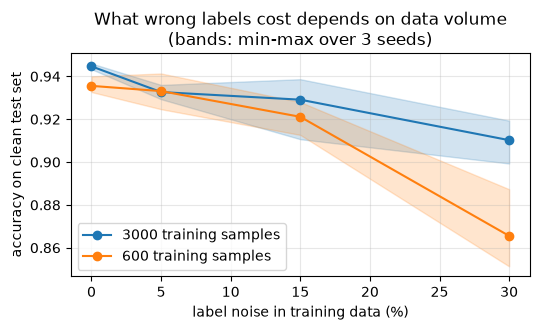

In [6]:
noise_levels = [0.0, 0.05, 0.15, 0.30]
regimes = {"3000 training samples": 3000, "600 training samples": 600}
sweep = {}                       # regime -> array of shape (noise levels, seeds)
for name, n in regimes.items():
    curves = []
    for p in noise_levels:
        accs = []
        for s in [1, 2, 3]:
            data = make_data(n_train=n, label_noise=p, seed=s)
            torch.manual_seed(s)
            model = MLP(width=128, depth=2)
            train_model(model, data, epochs=50, batch_size=128, seed=s)
            accs.append(accuracy(model, *data[4:6]))
        curves.append(accs)
        print(f"n={n:4d}  label noise {p:4.0%}  ->  clean-test accuracy "
              f"{np.mean(accs):.3f}  (seeds span {np.min(accs):.3f}-{np.max(accs):.3f})")
    sweep[name] = np.array(curves)

plt.figure(figsize=(5.5, 3.4))
x = np.array(noise_levels) * 100
for name, curves in sweep.items():
    line, = plt.plot(x, curves.mean(axis=1), "o-", label=name)
    plt.fill_between(x, curves.min(axis=1), curves.max(axis=1),
                     color=line.get_color(), alpha=0.2)
plt.xlabel("label noise in training data (%)")
plt.ylabel("accuracy on clean test set")
plt.legend(); plt.grid(alpha=0.3)
plt.title("What wrong labels cost depends on data volume\n(bands: min-max over 3 seeds)")
plt.tight_layout()


Dos regímenes, dos historias. Con 3000 muestras de entrenamiento, incluso un 30 % de etiquetas volteadas al azar cuesta poco: la entropía cruzada promedia sobre muchas muestras, los volteos son simétricos y la mayoría correcta sigue fijando las fronteras de clase. Con 600 muestras el mismo modelo tiene capacidad suficiente para memorizar las etiquetas volteadas en lugar de promediarlas fuera, y la exactitud cae varios puntos. El ruido en las etiquetas es más peligroso exactamente donde suelen vivir las geociencias: conjuntos etiquetados pequeños y modelos lo bastante grandes para memorizarlos. Las bandas sombreadas son el rango mín-máx sobre las tres semillas — la variabilidad entre corridas que un experimento de una sola semilla esconde. Lea las bandas antes de confiar en cualquier diferencia entre dos puntos: donde las bandas se solapan, la diferencia puede ser suerte de inicialización, no la perilla que usted giró. Aquí el rango no es decoración: con 3000 muestras las tres semillas abarcan hasta 0.028 (con 15 % de ruido) — la mayor parte del 0.035 que separa las medias del caso limpio y el de 30 % de ruido —, así que una versión de esta figura con una sola semilla podría haber contado casi cualquier historia. Cada número resumen de este laboratorio que provenga de corridas repetidas se reporta ahora con su rango entre semillas.

**Qué buscar en datos reales.** Una exactitud de validación que se estanca por debajo de lo que sugiere el solapamiento de clases es un síntoma de calidad de etiquetas, no un problema de arquitectura. Para detectarlo: inspeccione las muestras en las que el modelo se «equivoca» con más confianza (a menudo están mal etiquetadas, no mal clasificadas), pida a un segundo analista que reetiquete un subconjunto aleatorio y mida el acuerdo, y coteje las etiquetas contra catálogos independientes. Y recuerde que el ruido que hace daño en la práctica rara vez es simétrico: un analista que confunde sistemáticamente dos tipos de señal sesga la propia frontera, lo que es mucho peor que los volteos aleatorios — el próximo experimento mide exactamente eso. Arreglar mil etiquetas suele ganarle a agregar un millón de parámetros.

### 3.2 Desbalance de clases

La andesita ya es la clase rara. Ahora la encogemos aún más y observamos la exhaustividad (*recall*) por clase, no la exactitud global.

#### Desacuerdo estructurado: cuando los errores tienen un patrón

Los volteos aleatorios uniformes son el error de etiquetas más benigno posible, y el experimento de arriba muestra por qué: con suficientes datos se promedian y desaparecen. Los errores de etiquetas reales vienen de personas, y las personas discrepan con patrones. Simulamos una campaña de campo mapeada por dos geólogos que se repartieron el área. Cada uno etiqueta mal el 30 % de sus muestras — la misma tasa de error total que el experimento uniforme más duro de arriba — pero sus confusiones nunca son aleatorias: el granito se desliza hacia la andesita, el basalto se desliza hacia la andesita, la andesita hacia cualquiera de sus vecinos. Nadie llama nunca granito a un basalto. La confusión se concentra entre litologías *adyacentes* en el eje de diferenciación, que es exactamente como se comporta el desacuerdo real en el mapeo.

El mismo régimen de 3000 muestras, el mismo modelo, el mismo presupuesto de entrenamiento; solo cambia el patrón del error.


no label errors                 : clean-test accuracy 0.945  (seeds span 0.943-0.946)
30% uniform flips               : clean-test accuracy 0.910  (seeds span 0.899-0.919)
30% adjacent-class disagreement : clean-test accuracy 0.820  (seeds span 0.799-0.850)


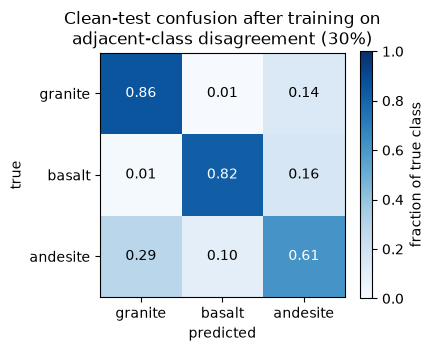

In [7]:
def two_mappers(rate, seed):
    '''Relabeling by two simulated mappers whose errors are only ever between
    adjacent lithologies (granite <-> andesite <-> basalt).'''
    confusion = {
        "A": {"granite": "andesite", "andesite": "granite", "basalt": "andesite"},
        "B": {"granite": "andesite", "andesite": "basalt", "basalt": "andesite"},
    }
    def relabel(frame):
        rng = np.random.default_rng(seed)
        out = frame.copy()
        labels = out["label"].to_numpy().copy()
        is_B = rng.random(len(out)) < 0.5           # who logged each sample
        err = rng.random(len(out)) < rate
        for k in np.where(err)[0]:
            labels[k] = confusion["B" if is_B[k] else "A"][labels[k]]
        out["label"] = labels
        return out
    return relabel

rate = 0.30
adj_accs, confmats = [], []
for s in [1, 2, 3]:
    data = make_data(n_train=3000, relabel=two_mappers(rate, seed=s), seed=s)
    torch.manual_seed(s)
    model = MLP(width=128, depth=2)
    train_model(model, data, epochs=50, batch_size=128, seed=s)
    adj_accs.append(accuracy(model, *data[4:6]))
    model.eval()
    with torch.no_grad():
        pred = model(data[4].to(device)).argmax(1).cpu().numpy()
    confmats.append(confusion_matrix(data[5].numpy(), pred, labels=[0, 1, 2]))

uniform_accs = sweep["3000 training samples"][noise_levels.index(0.30)]
clean_accs = sweep["3000 training samples"][noise_levels.index(0.0)]
for name, accs in [("no label errors", clean_accs),
                   ("30% uniform flips", uniform_accs),
                   ("30% adjacent-class disagreement", adj_accs)]:
    print(f"{name:32s}: clean-test accuracy {np.mean(accs):.3f}  "
          f"(seeds span {np.min(accs):.3f}-{np.max(accs):.3f})")

cm = np.mean(confmats, axis=0)
cm = cm / cm.sum(axis=1, keepdims=True)             # row-normalized (recall)
fig, ax = plt.subplots(figsize=(4.4, 3.6))
im = ax.imshow(cm, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(3)); ax.set_xticklabels(CLASSES)
ax.set_yticks(range(3)); ax.set_yticklabels(CLASSES)
for r in range(3):
    for c_ in range(3):
        ax.text(c_, r, f"{cm[r, c_]:.2f}", ha="center", va="center",
                color="white" if cm[r, c_] > 0.5 else "black")
ax.set_xlabel("predicted"); ax.set_ylabel("true")
ax.set_title("Clean-test confusion after training on\nadjacent-class disagreement (30%)")
plt.colorbar(im, ax=ax, label="fraction of true class")
plt.tight_layout()


La misma tasa de error, el triple de daño: el 30 % de volteos uniformes cuesta 3.5 puntos de exactitud (de 0.945 a 0.910), el 30 % de desacuerdo entre clases adyacentes cuesta 12.5 (de 0.945 a 0.820), y ninguna semilla se acerca a cerrar la brecha (la mejor semilla: 0.850). La matriz de confusión muestra adónde se fueron los puntos. Ambos mapeadores vuelcan sus errores en «andesita», así que el modelo aprendió una clase andesita que se anexa las zonas fronterizas de sus vecinas: el 14 % de los granitos verdaderos y el 16 % de los basaltos verdaderos ahora regresan como «andesita», mientras que la exhaustividad de la andesita verdadera cae a 0.61. Y este es el régimen de 3000 muestras — aquel donde los volteos uniformes salían casi gratis.

Este resultado importa mucho más allá de este cuaderno, así que aquí va sin el código. Cada etiqueta de un conjunto de datos geocientífico es una interpretación, no una medición. Un mapa geológico registra lo que un mapeador concluyó a partir de afloramientos, fragmentos sueltos y decisiones de criterio en los contactos; un *pick* de fase sísmica registra dónde un analista decidió que llegó la onda; un inventario de deslizamientos registra qué rasgos de ladera un intérprete aceptó como fallas de talud. Envíe a dos expertos calificados sobre el mismo terreno, las mismas formas de onda o las mismas imágenes de manera independiente y discreparán — casi siempre entre categorías *adyacentes*: granodiorita contra granito, Pn contra P, deslizamiento antiguo contra morrena de montículos. Ese desacuerdo es medible (mapee dos veces un subconjunto, marque dos veces un día de registros) y es rutinariamente un porcentaje de dos dígitos en las fronteras entre categorías.

El desacuerdo estructurado duele más que el error aleatorio porque vota de manera coherente. Mil volteos aleatorios se dispersan en todas direcciones y se cancelan; mil confusiones entre clases adyacentes empujan la misma frontera de clase en la misma dirección, así que más datos hacen al modelo *más* confiado en el error compartido de los mapeadores, no menos. La consecuencia práctica: el acuerdo entre evaluadores es un techo para la exactitud que cualquier modelo puede demostrar, porque el modelo se califica contra etiquetas que cargan con el desacuerdo. Antes de gastar un mes en arquitecturas, gaste un día midiendo con qué frecuencia dos expertos coinciden en sus etiquetas — ese número le dice cuándo dejar de ajustar y empezar a reetiquetar.


               overall acc  recall granite  recall basalt  recall andesite
minority kept                                                             
1.00                 0.946           0.972          0.967            0.735
0.50                 0.949           0.984          0.975            0.677
0.20                 0.915           0.984          0.981            0.329
0.05                 0.881           0.984          0.981            0.000


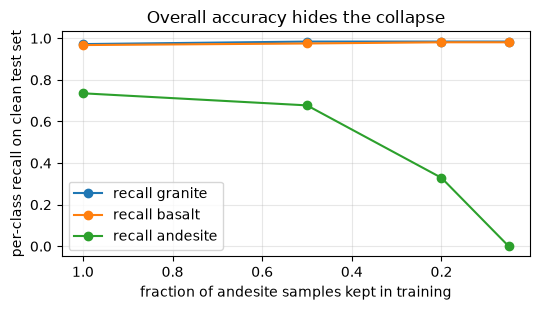

In [8]:
keep_fractions = [1.0, 0.5, 0.2, 0.05]
rows = []
for keep in keep_fractions:
    data = make_data(minority_keep=keep, seed=2)
    torch.manual_seed(2)
    model = MLP(width=32, depth=2)
    train_model(model, data, epochs=25, seed=2)
    Xte, yte = data[4], data[5]
    model.eval()
    with torch.no_grad():
        pred = model(Xte.to(device)).argmax(1).cpu().numpy()
    rec = recall_score(yte.numpy(), pred, average=None, labels=[0, 1, 2])
    rows.append({"minority kept": keep, "overall acc": (pred == yte.numpy()).mean(),
                 **{f"recall {c}": r for c, r in zip(CLASSES, rec)}})

imbalance = pd.DataFrame(rows).set_index("minority kept")
print(imbalance.round(3))

imbalance[[f"recall {c}" for c in CLASSES]].plot(marker="o", figsize=(5.5, 3.2))
plt.xlabel("fraction of andesite samples kept in training")
plt.ylabel("per-class recall on clean test set")
plt.grid(alpha=0.3); plt.gca().invert_xaxis()
plt.title("Overall accuracy hides the collapse")
plt.tight_layout()

Lea las dos columnas una contra la otra. La exactitud global baja unos pocos puntos — nada alarmante en un tablero de control. La exhaustividad de la andesita colapsa a cero: el modelo dejó de predecir la clase por completo. Note también que incluso con todos los datos la clase rara arranca en desventaja (exhaustividad de 0.74 contra 0.97 de las clases mayoritarias). Esta es la falla silenciosa más común en la clasificación geocientífica, donde la clase rara (la erupción, el evento inducido, el deslizamiento) es la que a usted le importa.

**Qué buscar en datos reales.** Reporte siempre la matriz de confusión completa y la exhaustividad por clase; nunca la exactitud sola. Si la clase minoritaria importa, use pesos de clase en la pérdida, sobremuestréela o genere ejemplos minoritarios aumentados — y verifique que el arreglo aparezca en la exhaustividad, no solo en la pérdida.

### 3.3 Ruido de sensores en las características

Ahora las etiquetas están bien pero el instrumento se degrada: agregamos ruido gaussiano extra a las características de entrenamiento y validación, sobre el piso de medición compartido de 1.0$\sigma$, en unidades de una desviación estándar de cada característica. El conjunto de prueba conserva el piso normal — esto simula entrenar con datos de un sensor peor que el que usted despliega.

extra sensor noise 0.0 sigma  ->  clean-test accuracy 0.950


extra sensor noise 2.0 sigma  ->  clean-test accuracy 0.928


extra sensor noise 4.0 sigma  ->  clean-test accuracy 0.876


extra sensor noise 8.0 sigma  ->  clean-test accuracy 0.785


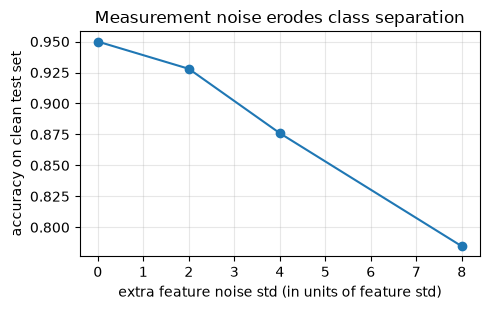

In [9]:
sensor_levels = [0.0, 2.0, 4.0, 8.0]
sensor_accs = []
for s in sensor_levels:
    data = make_data(feature_noise=s, seed=3)
    torch.manual_seed(3)
    model = MLP(width=64, depth=2)
    train_model(model, data, epochs=25, seed=3)
    sensor_accs.append(accuracy(model, *data[4:6]))
    print(f"extra sensor noise {s:.1f} sigma  ->  clean-test accuracy {sensor_accs[-1]:.3f}")

plt.figure(figsize=(5, 3.2))
plt.plot(sensor_levels, sensor_accs, "o-")
plt.xlabel("extra feature noise std (in units of feature std)")
plt.ylabel("accuracy on clean test set")
plt.grid(alpha=0.3); plt.title("Measurement noise erodes class separation")
plt.tight_layout()

Una vez que el ruido agregado alcanza unas cuantas veces la dispersión natural de cada característica, los cúmulos de clase se embarran unos con otros y la exactitud resbala hacia el nivel del azar. Ningún modelo recupera una separación que las mediciones ya no contienen — este es el término de error irreducible de la sección 2.5 hecho visible.

**Qué buscar en datos reales.** Estime la incertidumbre de medición por característica (mediciones repetidas, especificaciones del instrumento, registros de calibración) y compárela con la separación entre clases de esa característica. Las características cuyo ruido supera su separación entre clases no agregan señal; limpiarlas o descartarlas es curaduría de datos, no una derrota.

### 3.4 ¿Cuántos datos son suficientes?

El diagnóstico clásico de la curva de aprendizaje grafica el desempeño contra el tamaño del conjunto de entrenamiento. Esta es la función a reutilizar cada vez que alguien pregunte «¿ayudarían más datos?» — una pregunta que se mide mejor de lo que se debate.

#### Calidad heterocedástica: cuando usted sabe qué tan ruidosa es cada muestra

El barrido de arriba degradó todas las muestras por igual. Las tablas reales mezclan procedencias: la mitad de su geoquímica de un XRF de laboratorio con error analítico ajustado, la otra mitad de una unidad portátil de campo varias veces peor — y los metadatos normalmente dicen cuál es cuál, porque la incertidumbre analítica se reporta por muestra. (Los flujos de sensores hacen lo mismo en el tiempo: `mlgeo_synth.degrade_series` devuelve una columna `sigma_mm` por muestra exactamente por esta razón.) El ruido cuya varianza cambia de muestra a muestra se llama **heterocedástico**, y es la mitad aleatoria del vocabulario de incertidumbre de la lección 3.9: azar en la propia medición, que ninguna cantidad de datos de entrenamiento elimina — pero que usted puede negarse a tratar como verdad.

La entropía cruzada estándar trata a cada muestra como igualmente confiable. Si la varianza se conoce, el arreglo es pesar la pérdida de cada muestra por el inverso de su varianza ($w_i \propto 1/\sigma_i^2$), el análogo en clasificación de los mínimos cuadrados ponderados. Medimos lo que cuesta ignorar los metadatos y lo que los pesos recuperan: cada muestra de entrenamiento sortea su piso de ruido de {0.5, 4.0} desviaciones estándar con igual probabilidad (grado de laboratorio o grado de campo), y el mismo modelo entrena una vez sin los pesos y una vez con ellos.


In [10]:
mix = (0.5, 4.0)          # each training sample: lab-grade or field-grade noise


def train_weighted(model, data, weights, epochs=25, lr=1e-3, batch_size=256, seed=0):
    '''Minibatch training with a per-sample weight inside the cross-entropy.'''
    Xtr, ytr = data[0], data[1]
    model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    per_sample = nn.CrossEntropyLoss(reduction="none")
    g = torch.Generator().manual_seed(seed)
    n = len(Xtr)
    for _ in range(epochs):
        model.train()
        for i in range(0, n, batch_size):
            idx = torch.randperm(n, generator=g)[:batch_size]
            opt.zero_grad()
            loss = (per_sample(model(Xtr[idx].to(device)), ytr[idx].to(device))
                    * weights[idx].to(device)).mean()
            loss.backward()
            opt.step()


hetero_accs = {}
for scheme in ["ignore the metadata", "inverse-variance weights"]:
    accs = []
    for s in [1, 2, 3]:
        *data6, sigma = make_data(n_train=3000, hetero_sigma=mix, seed=s)
        w = 1.0 / sigma**2
        w = w / w.mean()                     # normalize so the lr keeps its meaning
        torch.manual_seed(s)
        model = MLP(width=64, depth=2)
        if scheme == "ignore the metadata":
            train_model(model, tuple(data6), epochs=25, seed=s)
        else:
            train_weighted(model, tuple(data6), w, epochs=25, seed=s)
        accs.append(accuracy(model, *data6[4:6]))
    hetero_accs[scheme] = accs
    print(f"{scheme:26s}: clean-test accuracy {np.mean(accs):.3f}  "
          f"(seeds span {np.min(accs):.3f}-{np.max(accs):.3f})")
print(f"{'all lab-grade (reference)':26s}: clean-test accuracy {sensor_accs[0]:.3f}"
      "   (the sensor sweep at 0 extra noise)")


ignore the metadata       : clean-test accuracy 0.933  (seeds span 0.932-0.935)


inverse-variance weights  : clean-test accuracy 0.946  (seeds span 0.939-0.951)
all lab-grade (reference) : clean-test accuracy 0.950   (the sensor sweep at 0 extra noise)


La tabla de calidad mixta cuesta 1.7 puntos frente a la referencia toda de grado de laboratorio (0.933 contra 0.950). Entregarle al modelo la varianza que ya tenía en los metadatos recupera 1.3 de ellos (0.946) — sin datos nuevos, con una línea de código en la pérdida — y las bandas de semillas de los dos esquemas no se solapan (0.932-0.935 contra 0.939-0.951), así que la ganancia no es suerte de inicialización.

**Qué buscar en datos reales.** Cualquier columna llamada `uncertainty`, `std_err`, `quality` o `pick_weight` es una invitación a pesar la pérdida — los catálogos sísmicos, las bases de datos geoquímicas y las soluciones GNSS traen todas una, y la mayoría de los *pipelines* (flujos de procesamiento) la descarta al ingerir los datos. Bajar el peso es además la alternativa honesta al atajo tentador de borrar la mitad ruidosa: las muestras de grado de campo todavía llevan señal, solo que menos por muestra, y los pesos le ponen precio a eso.


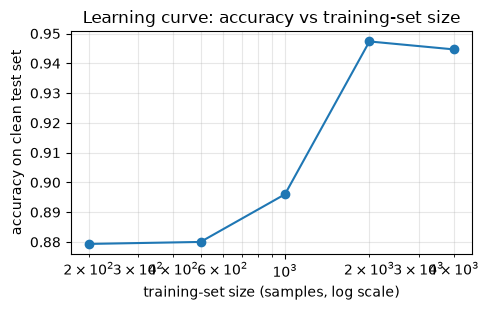

In [11]:
def plot_learning_curves(sizes, width=32, depth=2, epochs=25, seed=4):
    '''Test accuracy as a function of training-set size (Pillar 1 diagnostic).'''
    accs = []
    for n in sizes:
        data = make_data(n_train=n, seed=seed)
        torch.manual_seed(seed)
        model = MLP(width=width, depth=depth)
        train_model(model, data, epochs=epochs, seed=seed)
        accs.append(accuracy(model, *data[4:6]))
    plt.figure(figsize=(5, 3.2))
    plt.semilogx(sizes, accs, "o-")
    plt.xlabel("training-set size (samples, log scale)")
    plt.ylabel("accuracy on clean test set")
    plt.grid(alpha=0.3, which="both")
    plt.title("Learning curve: accuracy vs training-set size")
    plt.tight_layout()
    return accs

sizes = [200, 500, 1000, 2000, 4000]
accs_vs_size = plot_learning_curves(sizes)

La curva sube con pendiente fuerte y luego se aplana: pasadas unas pocas miles de muestras, más datos idénticos compran poco. Si la curva todavía sube con su tamaño de datos actual, recolecte más datos antes de ajustar cualquier otra cosa. Si ya se aplanó, más datos iguales no ayudarán; mejores etiquetas, mejores características o ejemplos más difíciles podrían.

```{admonition} Punto de control del laboratorio — un corte natural para un laboratorio de dos sesiones
:class: tip
El Pilar 1 termina aquí, y este es el lugar para detenerse si corre el cuaderno en dos sesiones de clase. Sesión 1: preparación y curaduría de los datos de entrenamiento (secciones 1-3). Sesión 2: arquitectura, incertidumbre, comportamiento fuera de rango y estrategias de entrenamiento (secciones 4-5). Para retomar, reinicie el *kernel*, corra las celdas de preparación y de ayudantes de la sección 1 y continúe desde la sección 4 — nada de lo de abajo depende de los barridos del Pilar 1, salvo las tablas resumen que ya vio.
```

## 4. Pilar 2 — Arquitectura

Con los datos limpios y fijos, ahora variamos el modelo. Las preguntas son siempre las mismas: qué tan ancho, qué tan profundo y comparado con qué modelo de referencia.

### 4.1 Ancho

   width  params  test acc
0      4      75  0.852000
1     16     483  0.882667
2     64    4995  0.951333
3    256   69123  0.949333


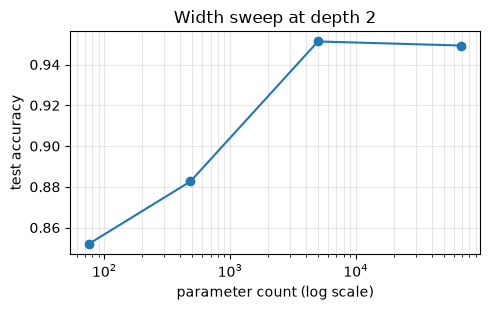

In [12]:
data = make_data(seed=5)

widths = [4, 16, 64, 256]
rows = []
for w in widths:
    torch.manual_seed(5)
    model = MLP(width=w, depth=2)
    train_model(model, data, epochs=25, seed=5)
    rows.append({"width": w, "params": count_params(model),
                 "test acc": accuracy(model, *data[4:6])})
width_sweep = pd.DataFrame(rows)
print(width_sweep)

plt.figure(figsize=(5, 3.2))
plt.semilogx(width_sweep["params"], width_sweep["test acc"], "o-")
plt.xlabel("parameter count (log scale)")
plt.ylabel("test accuracy")
plt.grid(alpha=0.3, which="both"); plt.title("Width sweep at depth 2")
plt.tight_layout()

La exactitud se satura a unas pocas veces el ancho mínimo adecuado. Pasado ese punto, los parámetros son gratis en exactitud pero no en tiempo de entrenamiento, memoria ni riesgo de sobreajuste en conjuntos más pequeños.

### 4.2 Profundidad con presupuesto de parámetros fijo

¿Es mejor gastar un presupuesto fijo de parámetros en profundidad o en ancho? Resolvemos el ancho que le da a cada profundidad aproximadamente el mismo conteo de parámetros, y luego comparamos.

In [13]:
def width_for_budget(depth, budget=5000):
    '''Smallest width whose MLP meets or exceeds the parameter budget.'''
    for w in range(1, 1024):
        if count_params(MLP(width=w, depth=depth)) >= budget:
            return w
    return 1024

rows = []
for d in [1, 2, 4]:
    w = width_for_budget(d)
    torch.manual_seed(6)
    model = MLP(width=w, depth=d)
    train_model(model, data, epochs=25, seed=6)
    rows.append({"depth": d, "width": w, "params": count_params(model),
                 "test acc": accuracy(model, *data[4:6])})
depth_sweep = pd.DataFrame(rows)
print(depth_sweep)

   depth  width  params  test acc
0      1    385    5008  0.952000
1      2     65    5138  0.954667
2      4     39    5190  0.950667


En un problema tabular de 9 características, la profundidad compra poco: las correlaciones que el generador plantó son de bajo orden, y una red superficial-pero-ancha las representa tan bien como una profunda. La profundidad paga cuando los datos tienen estructura jerárquica — bordes a texturas a objetos en imágenes (cuaderno 4.3), muestras a motivos a frases en secuencias (cuaderno 4.4). Empareje la arquitectura con la estructura de los datos, no con la moda.

### 4.3 El modelo de referencia que siempre debe correr

Todo modelo profundo necesita un punto de referencia barato. Para clasificación, ese es la regresión logística multinomial — equivalentemente, nuestro MLP con profundidad 0 (una sola capa lineal más softmax).

In [14]:
torch.manual_seed(7)
logistic = MLP(width=1, depth=0)     # depth=0 -> a single linear layer
train_model(logistic, data, epochs=25, seed=7)
torch.manual_seed(7)
best_mlp = MLP(width=64, depth=2)
train_model(best_mlp, data, epochs=25, seed=7)

print(f"logistic baseline ({count_params(logistic):5d} params): "
      f"test acc {accuracy(logistic, *data[4:6]):.3f}")
print(f"MLP 64x2          ({count_params(best_mlp):5d} params): "
      f"test acc {accuracy(best_mlp, *data[4:6]):.3f}")

logistic baseline (   30 params): test acc 0.879
MLP 64x2          ( 4995 params): test acc 0.953


La brecha es real pero modesta — típica de datos tabulares bien comportados. Si su modelo profundo no puede vencer al modelo de referencia lineal, el problema son los datos o las características, no una capa faltante. Reporte el modelo de referencia en cada proyecto; es el denominador honesto de toda afirmación sobre aprendizaje profundo.

### 4.4 Ensambles profundos: incertidumbre a partir del desacuerdo

Entrene la misma arquitectura desde varias semillas aleatorias y las corridas convergen a funciones distintas que coinciden en las muestras fáciles y discrepan cerca de las fronteras de clase. Ese desacuerdo es una señal práctica de incertidumbre (Lakshminarayanan et al., 2017, *NeurIPS*), y no cuesta nada salvo entrenar repetidamente. Si la señal es *buena* o no, no es algo que se afirme; se divide en dos aseveraciones medibles. **Discriminación**: ¿el desacuerdo ordena las muestras por su riesgo de error? **Calibración**: cuando el ensamble dice 80 %, ¿acierta alrededor del 80 % de las veces? Las dos son independientes — un modelo puede ordenar sus errores perfectamente mientras cada probabilidad que declara está 20 puntos pasada de confianza — y medimos ambas.

In [15]:
n_members = 5
member_probs, member_accs = [], []
Xte, yte = data[4], data[5]
for s in range(n_members):
    torch.manual_seed(100 + s)                  # different init per member
    member = MLP(width=64, depth=2)
    train_model(member, data, epochs=25, seed=100 + s)  # different batches too
    member.eval()
    with torch.no_grad():
        probs = torch.softmax(member(Xte.to(device)), dim=1).cpu().numpy()
    member_probs.append(probs)
    member_accs.append(accuracy(member, Xte, yte))

member_probs = np.stack(member_probs)           # (members, samples, classes)
ens_mean = member_probs.mean(axis=0)
ens_pred = ens_mean.argmax(1)
ens_acc = (ens_pred == yte.numpy()).mean()
# disagreement: std across members of the probability of the ensemble's chosen class
ens_std = member_probs.std(axis=0)[np.arange(len(yte)), ens_pred]

print("member accuracies:", np.round(member_accs, 3))
print(f"ensemble-mean accuracy: {ens_acc:.3f}")

member accuracies: [0.952 0.949 0.951 0.949 0.949]
ensemble-mean accuracy: 0.949


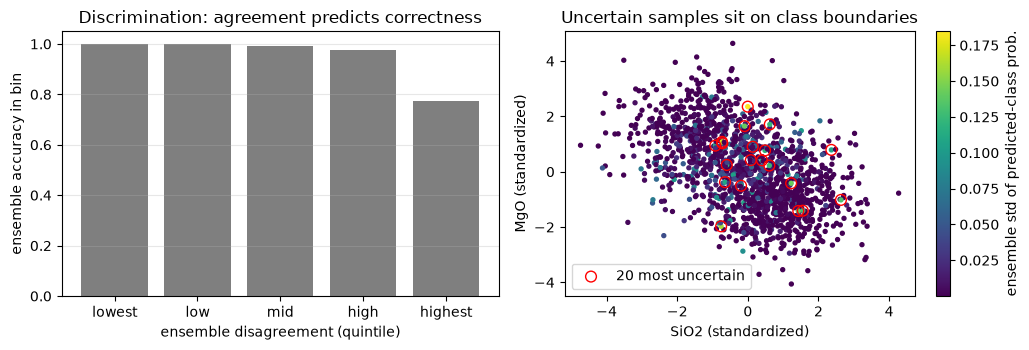

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(10.5, 3.6))

# discrimination check: accuracy within quintiles of ensemble disagreement
bins = np.quantile(ens_std, np.linspace(0, 1, 6))
bin_idx = np.clip(np.digitize(ens_std, bins[1:-1]), 0, 4)
correct = ens_pred == yte.numpy()
bin_acc = [correct[bin_idx == b].mean() for b in range(5)]
ax[0].bar(range(5), bin_acc, color="tab:gray")
ax[0].set_xticks(range(5))
ax[0].set_xticklabels(["lowest", "low", "mid", "high", "highest"])
ax[0].set_xlabel("ensemble disagreement (quintile)")
ax[0].set_ylabel("ensemble accuracy in bin")
ax[0].set_title("Discrimination: agreement predicts correctness")
ax[0].grid(alpha=0.3, axis="y")

# where the uncertain samples live in feature space
sio2 = Xte[:, FEATURES.index("SIO2")].numpy()
mgo = Xte[:, FEATURES.index("MGO")].numpy()
sc = ax[1].scatter(sio2, mgo, c=ens_std, s=8, cmap="viridis")
flag = np.argsort(ens_std)[-20:]                # 20 most uncertain samples
ax[1].scatter(sio2[flag], mgo[flag], facecolors="none",
              edgecolors="red", s=60, label="20 most uncertain")
plt.colorbar(sc, ax=ax[1], label="ensemble std of predicted-class prob.")
ax[1].set_xlabel("SiO2 (standardized)"); ax[1].set_ylabel("MgO (standardized)")
ax[1].set_title("Uncertain samples sit on class boundaries")
ax[1].legend()
plt.tight_layout()

Dos recompensas. Primero, la media del ensamble suele ser al menos tan exacta como el mejor miembro individual. Segundo — y más útil en la práctica —, las muestras donde los miembros discrepan son exactamente las muestras en las que el ensamble se equivoca más a menudo, y se agrupan a lo largo de las fronteras de clase en el espacio de características. En un flujo de trabajo real, usted enviaría las muestras marcadas a un analista humano. Esto es **discriminación** — la misma destreza que tenía la dispersión de votos de la lección 3.9, medida de la misma manera: agrupe por el puntaje de incertidumbre y verifique que la exactitud caiga a lo largo de los grupos. Nada en esta figura dice si las *probabilidades* del ensamble significan lo que afirman. El hito del proyecto final ofrece este análisis como uno de los dos experimentos de incertidumbre requeridos.

## 5. Pilar 3 — Estrategias de entrenamiento

Los mismos datos, la misma arquitectura: todo lo de abajo cambia solo cómo entrenamos.

### 5.1 La tasa de aprendizaje, de tres maneras
Esa segunda propiedad es la **calibración**, y necesita las herramientas de la lección 3.6: un diagrama de confiabilidad sobre las probabilidades medias del ensamble, resumido por el **error de calibración esperado** (ECE) — la brecha promedio entre la confianza declarada y la exactitud observada, ponderada por cuántas muestras caen en cada casilla de confianza. Para un problema de 3 clases la confianza de la clase predicha vive entre 1/3 y 1, así que las casillas también. Comparamos la media del ensamble contra un miembro individual para ver qué compra el promedio.


single member    accuracy 0.952   ECE 0.015
ensemble mean    accuracy 0.949   ECE 0.017


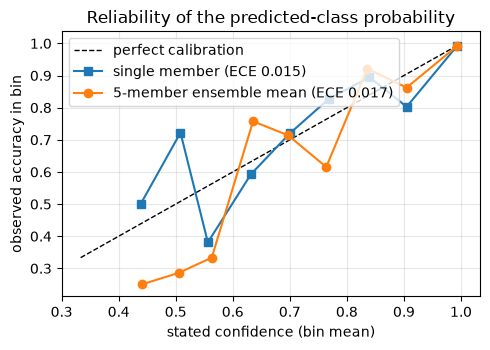

In [17]:
def reliability(probs, y_true, n_bins=10):
    '''Top-label reliability: bin samples by predicted-class confidence.
    Returns per-bin mean confidence, per-bin accuracy, counts, and ECE.'''
    conf = probs.max(axis=1)
    correct = probs.argmax(axis=1) == y_true
    edges = np.linspace(1 / 3, 1.0, n_bins + 1)     # 3 classes: confidence >= 1/3
    idx = np.clip(np.digitize(conf, edges[1:-1]), 0, n_bins - 1)
    counts = np.bincount(idx, minlength=n_bins)
    bin_conf = np.array([conf[idx == b].mean() if counts[b] else np.nan
                         for b in range(n_bins)])
    bin_acc = np.array([correct[idx == b].mean() if counts[b] else np.nan
                        for b in range(n_bins)])
    ok = counts > 0
    ece = np.sum(np.abs(bin_acc[ok] - bin_conf[ok]) * counts[ok]) / counts.sum()
    return bin_conf, bin_acc, counts, ece


y_np = yte.numpy()
bc_s, ba_s, _, ece_single = reliability(member_probs[0], y_np)
bc_e, ba_e, _, ece_ens = reliability(ens_mean, y_np)

plt.figure(figsize=(5, 3.6))
plt.plot([1 / 3, 1], [1 / 3, 1], "k--", lw=1, label="perfect calibration")
plt.plot(bc_s, ba_s, "s-", label=f"single member (ECE {ece_single:.3f})")
plt.plot(bc_e, ba_e, "o-", label=f"5-member ensemble mean (ECE {ece_ens:.3f})")
plt.xlabel("stated confidence (bin mean)")
plt.ylabel("observed accuracy in bin")
plt.legend(); plt.grid(alpha=0.3)
plt.title("Reliability of the predicted-class probability")
plt.tight_layout()

print(f"single member    accuracy {(member_probs[0].argmax(1) == y_np).mean():.3f}"
      f"   ECE {ece_single:.3f}")
print(f"ensemble mean    accuracy {ens_acc:.3f}   ECE {ece_ens:.3f}")


La medición corrige la afirmación que hacía un borrador anterior de esta sección. Lakshminarayanan et al. (2017) encontraron que los ensambles profundos mejoran la calibración, y en redes profundas — especialmente bajo cambio de distribución — en general lo hacen. Aquí el miembro individual ya está casi calibrado (ECE 0.015) y la media del ensamble no gana nada medible (ECE 0.017; ambas curvas se pegan a la diagonal). Un MLP de dos capas sobre nueve características con un piso de ruido de 1$\sigma$ no está lo bastante descalibrado como para arreglarlo. «Bien calibrado» es una medición que usted le adjunta a un modelo después de correr esta celda, no un adjetivo que viene incluido con un método.

Mantenga los dos diagnósticos separados en sus reportes. La gráfica por quintiles responde *«¿puedo confiar en el ordenamiento?»* — útil para enviar muestras a un analista, donde solo el orden importa. El diagrama de confiabilidad responde *«¿puedo confiar en el número?»* — requerido siempre que la probabilidad misma alimente un umbral de decisión que pertenece a otra persona, la situación sobre la que advirtió la lección 3.6. Reportar uno como evidencia del otro es el error exacto que esta sección contenía originalmente, y sobrevive a la revisión por pares con una frecuencia deprimente.


### 4.5 MC dropout: un segundo método de incertidumbre a partir de un solo modelo

Cinco corridas de entrenamiento son un costo real cuando una corrida toma una semana. El ***Monte Carlo dropout*** compra una estimación de incertidumbre a partir de un *único* modelo entrenado: entrene con *dropout* como de costumbre (la perilla que nuestro `MLP` carga desde la sección 2.6) y luego, al predecir, deje el *dropout* **encendido** y pase la misma entrada por la red $T$ veces. Cada pasada muestrea una subred aleatoria distinta; la media sobre las pasadas es la predicción y la dispersión sobre las pasadas es la incertidumbre — una aproximación a la inferencia bayesiana sobre los pesos (Gal & Ghahramani, 2016, *ICML*).

La comparación honesta es frente a frente sobre los mismos datos y el mismo conjunto de prueba: un modelo con *dropout* y $T=50$ pasadas estocásticas contra el ensamble de 5 miembros, calificados en exactitud, calibración (ECE) y discriminación (dispersión contra error), con el costo declarado junto a los números.


In [18]:
torch.manual_seed(150)
mc_model = MLP(width=64, depth=2, dropout=0.2)
train_model(mc_model, data, epochs=25, seed=150)

T = 50
torch.manual_seed(151)             # fixes which units drop in each pass
mc_model.train()                   # dropout stays ACTIVE at prediction time
with torch.no_grad():
    mc_probs = np.stack([
        torch.softmax(mc_model(Xte.to(device)), dim=1).cpu().numpy()
        for _ in range(T)])
mc_model.eval()

mc_mean = mc_probs.mean(axis=0)
mc_pred = mc_mean.argmax(1)
mc_acc = (mc_pred == y_np).mean()
mc_std = mc_probs.std(axis=0)[np.arange(len(yte)), mc_pred]
bc_m, ba_m, _, ece_mc = reliability(mc_mean, y_np)

head_to_head = pd.DataFrame({
    "deep ensemble (5 members)": {"test accuracy": round(ens_acc, 3),
                                  "ECE": round(ece_ens, 3),
                                  "models trained": 5, "prediction passes": 5},
    f"MC dropout (T={T})": {"test accuracy": round(mc_acc, 3),
                            "ECE": round(ece_mc, 3),
                            "models trained": 1, "prediction passes": T},
}).T
print(head_to_head)


                           test accuracy    ECE  models trained  \
deep ensemble (5 members)          0.949  0.017             5.0   
MC dropout (T=50)                  0.952  0.011             1.0   

                           prediction passes  
deep ensemble (5 members)                5.0  
MC dropout (T=50)                       50.0  


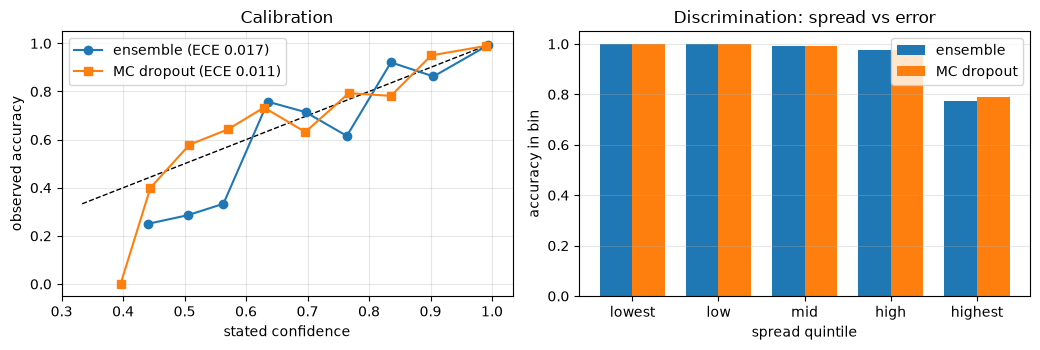

In [19]:
def quintile_accuracy(spread, pred, y_true):
    '''Accuracy within quintiles of an uncertainty score (discrimination).'''
    edges = np.quantile(spread, np.linspace(0, 1, 6))
    idx = np.clip(np.digitize(spread, edges[1:-1]), 0, 4)
    correct = pred == y_true
    return [correct[idx == b].mean() for b in range(5)]


fig, ax = plt.subplots(1, 2, figsize=(10.5, 3.6))
ax[0].plot([1 / 3, 1], [1 / 3, 1], "k--", lw=1)
ax[0].plot(bc_e, ba_e, "o-", label=f"ensemble (ECE {ece_ens:.3f})")
ax[0].plot(bc_m, ba_m, "s-", label=f"MC dropout (ECE {ece_mc:.3f})")
ax[0].set_xlabel("stated confidence"); ax[0].set_ylabel("observed accuracy")
ax[0].set_title("Calibration"); ax[0].legend(); ax[0].grid(alpha=0.3)

xq = np.arange(5)
ax[1].bar(xq - 0.19, quintile_accuracy(ens_std, ens_pred, y_np), 0.38,
          label="ensemble")
ax[1].bar(xq + 0.19, quintile_accuracy(mc_std, mc_pred, y_np), 0.38,
          label="MC dropout")
ax[1].set_xticks(xq)
ax[1].set_xticklabels(["lowest", "low", "mid", "high", "highest"])
ax[1].set_xlabel("spread quintile"); ax[1].set_ylabel("accuracy in bin")
ax[1].set_title("Discrimination: spread vs error")
ax[1].legend(); ax[1].grid(alpha=0.3, axis="y")
plt.tight_layout()


Los números se niegan a coronar al método caro. El *MC dropout* iguala al ensamble en exactitud (0.952 contra 0.949 — una diferencia dentro del rango de semillas de una sola corrida), le gana por poco en calibración (ECE 0.011 contra 0.017) y dibuja la misma curva de discriminación (exactitud en el quintil de mayor dispersión 0.79 contra 0.77; los otros cuatro quintiles coinciden a tres decimales) — por una corrida de entrenamiento en lugar de cinco. Las 50 pasadas de predicción son el lado barato del balance; las corridas de entrenamiento son el caro. En esta tarea, un modelo con *dropout* es la elección racional. Las razones por las que el ensamble sobrevive en la práctica quedan fuera de esta tabla: su ventaja documentada de calibración aparece en redes grandes bajo cambio de distribución, sus miembros entrenan en paralelo mientras que las pasadas de *dropout* a escala pueden embotellar la inferencia, y su desacuerdo proviene de soluciones genuinamente independientes — la propiedad que ahora llevamos fuera de rango.


### 4.6 Fuera de rango: interpolación, extrapolación y lo que el desacuerdo puede señalar

Hasta ahora, cada puntaje de este cuaderno comparte un supuesto escondido: el conjunto de prueba se sorteó del mismo generador, sobre los mismos rangos de parámetros, que el conjunto de entrenamiento. El modelo **interpola** — predice dentro de la región del espacio de características que sus datos de entrenamiento cubrieron. El despliegue rompe el supuesto rutinariamente: el área mapeada se acaba, el siguiente plutón es más evolucionado que cualquier cosa del muestreo, la estación nueva se asienta sobre suelo más blando. Predecir ahí es **extrapolación**, y la lección 3.8 mostró con su escalera de divisiones que interpolación y extrapolación son afirmaciones distintas — la división que usted elige decide cuál de las dos respalda su puntaje. Aquí observamos a un modelo cruzar la línea, y hacemos la pregunta operativa: ¿el desacuerdo del ensamble nos avisa cuando sucede?

El montaje usa la propia perilla escondida del generador. Los óxidos de cada muestra están gobernados por un **índice de diferenciación** latente (sección 1); su indicador observable es el SiO$_2$ estandarizado por clase. Entrenamos un ensamble solo con muestras dentro de una desviación estándar de la composición típica de cada unidad — la campaña de campo mapeó solo granitos típicos, basaltos típicos, andesitas típicas — y luego evaluamos sobre un sorteo fresco que abarca el rango completo, incluidos los extremos evolucionados y primitivos que el modelo nunca vio.


In [20]:
def diff_index(frame, stats=None):
    '''Per-class standardized SiO2: observable proxy for the latent
    differentiation index, the generator parameter we bound.'''
    if stats is None:
        stats = frame.groupby("label")["SIO2"].agg(["mean", "std"])
    mu = frame["label"].map(stats["mean"]).to_numpy()
    sd = frame["label"].map(stats["std"]).to_numpy()
    return (frame["SIO2"].to_numpy() - mu) / sd, stats


train_frame = mlgeo_synth.geochem_table(n=4000, seed=40)
z_train, z_stats = diff_index(train_frame)
bounded = train_frame[np.abs(z_train) <= 1.0]        # the "mapped" range
print(f"training keeps {len(bounded)} of {len(train_frame)} samples "
      "(|z| <= 1: the central ~68% of each unit's compositional range)")

test_frame = mlgeo_synth.geochem_table(n=3000, seed=41)   # fresh draw, FULL range
z_test, _ = diff_index(test_frame, z_stats)

Xb, yb = table_to_xy(bounded)
Xtr_b, Xva_b, ytr_b, yva_b = train_test_split(Xb, yb, test_size=0.25,
                                              random_state=40, stratify=yb)
Xte_f, yte_f = table_to_xy(test_frame)
scaler_b = StandardScaler().fit(Xtr_b)
Xtr_b, Xva_b, Xte_f = (scaler_b.transform(a) for a in (Xtr_b, Xva_b, Xte_f))
rngs = [np.random.default_rng(4000 + k) for k in range(3)]
Xtr_b, Xva_b, Xte_f = (a + r.normal(0, 1, a.shape)   # the usual 1-sigma noise floor
                       for a, r in zip((Xtr_b, Xva_b, Xte_f), rngs))
t32 = lambda a: torch.as_tensor(np.ascontiguousarray(a), dtype=torch.float32)
data_b = (t32(Xtr_b), torch.as_tensor(ytr_b), t32(Xva_b), torch.as_tensor(yva_b),
          t32(Xte_f), torch.as_tensor(yte_f))

ood_probs = []
for s in range(5):
    torch.manual_seed(200 + s)
    member = MLP(width=64, depth=2)
    train_model(member, data_b, epochs=25, seed=200 + s)
    member.eval()
    with torch.no_grad():
        ood_probs.append(torch.softmax(member(data_b[4].to(device)),
                                       dim=1).cpu().numpy())
ood_probs = np.stack(ood_probs)
ood_mean = ood_probs.mean(axis=0)
ood_pred = ood_mean.argmax(1)
ood_correct = ood_pred == yte_f
ood_std = ood_probs.std(axis=0)[np.arange(len(yte_f)), ood_pred]


training keeps 2723 of 4000 samples (|z| <= 1: the central ~68% of each unit's compositional range)


                                      n  error rate  mean disagreement
range                                                                 
in range (|z| <= 1)                2046       0.049              0.013
near extrapolation (1 < |z| <= 2)   824       0.080              0.017
far extrapolation (|z| > 2)         130       0.085              0.021

out-of-range errors: 77 on 954 out-of-range samples
silent failures (wrong AND disagreement at or below the in-range median): 1 of 77 (1% of out-of-range errors)


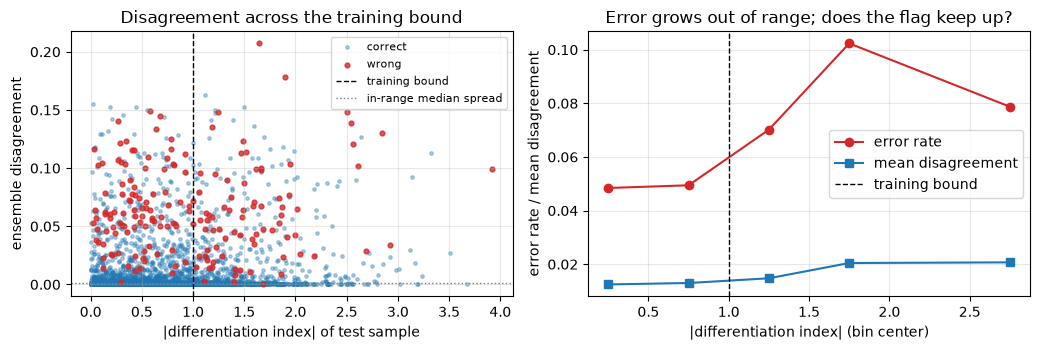

In [21]:
abs_z = np.abs(z_test)
groups = {"in range (|z| <= 1)": abs_z <= 1.0,
          "near extrapolation (1 < |z| <= 2)": (abs_z > 1.0) & (abs_z <= 2.0),
          "far extrapolation (|z| > 2)": abs_z > 2.0}
ood_table = pd.DataFrame(
    [{"range": g, "n": int(m.sum()),
      "error rate": 1 - ood_correct[m].mean(),
      "mean disagreement": ood_std[m].mean()} for g, m in groups.items()]
).set_index("range")
print(ood_table.round(3))

in_med = np.median(ood_std[groups["in range (|z| <= 1)"]])
wrong_ood = (abs_z > 1.0) & ~ood_correct
silent = wrong_ood & (ood_std <= in_med)     # wrong, yet looks as calm as in-range
print(f"\nout-of-range errors: {wrong_ood.sum()} on {int((abs_z > 1).sum())} "
      "out-of-range samples")
print(f"silent failures (wrong AND disagreement at or below the in-range median): "
      f"{silent.sum()} of {wrong_ood.sum()} "
      f"({silent.sum() / max(wrong_ood.sum(), 1):.0%} of out-of-range errors)")

fig, ax = plt.subplots(1, 2, figsize=(10.5, 3.6))
ax[0].scatter(abs_z[ood_correct], ood_std[ood_correct], s=6, alpha=0.35,
              label="correct")
ax[0].scatter(abs_z[~ood_correct], ood_std[~ood_correct], s=12, alpha=0.8,
              color="tab:red", label="wrong")
ax[0].axvline(1.0, color="k", ls="--", lw=1, label="training bound")
ax[0].axhline(in_med, color="tab:gray", ls=":", lw=1,
              label="in-range median spread")
ax[0].set_xlabel("|differentiation index| of test sample")
ax[0].set_ylabel("ensemble disagreement")
ax[0].set_title("Disagreement across the training bound")
ax[0].legend(fontsize=8); ax[0].grid(alpha=0.3)

edges = [0, 0.5, 1.0, 1.5, 2.0, 3.5]
centers, err_b, dis_b = [], [], []
for lo, hi in zip(edges[:-1], edges[1:]):
    m = (abs_z >= lo) & (abs_z < hi)
    if m.sum() < 10:
        continue
    centers.append((lo + hi) / 2)
    err_b.append(1 - ood_correct[m].mean())
    dis_b.append(ood_std[m].mean())
ax[1].plot(centers, err_b, "o-", color="tab:red", label="error rate")
ax[1].plot(centers, dis_b, "s-", color="tab:blue", label="mean disagreement")
ax[1].axvline(1.0, color="k", ls="--", lw=1, label="training bound")
ax[1].set_xlabel("|differentiation index| (bin center)")
ax[1].set_ylabel("error rate / mean disagreement")
ax[1].set_title("Error grows out of range; does the flag keep up?")
ax[1].legend(); ax[1].grid(alpha=0.3)
plt.tight_layout()


Lea primero la tabla. La tasa de error casi se duplica al cruzar la cota de entrenamiento — 4.9 % dentro del rango, 8.0 % apenas pasada, 8.5 % más allá de dos unidades — una falla gradual, porque un granito inusualmente evolucionado sigue siendo mayormente parecido a un granito. El desacuerdo medio sube con ella, de 0.013 a 0.021: el ensamble se da cuenta. Y de los 77 errores fuera de rango, exactamente uno es una **falla silenciosa** — equivocado, con un desacuerdo igual o menor que la mediana dentro del rango. Esa única muestra es el mecanismo a memorizar: una composición extrema que aterrizó dentro del territorio familiar de una clase *vecina*, así que los cinco miembros coincidieron con confianza en la misma etiqueta equivocada. El desacuerdo señala regiones no familiares del espacio de características; no puede señalar una muestra cuya etiqueta cambió mientras sus características llegaban a verse familiares. Bajo un cambio más grande, esa única muestra se convierte en una población.

La gráfica de dispersión agrega la segunda advertencia: las distribuciones de desacuerdo dentro y fuera de rango se solapan fuertemente. La media sube 60 %, pero ningún umbral sobre la dispersión reconstruye la cota de entrenamiento — la cota es un metadato que solo usted tiene, y por eso debe *declararse*, no inferirse del comportamiento del modelo.

**Su distribución de entrenamiento es un contrato.** Cada número que produjo este laboratorio — la exactitud, el ECE, las gráficas por quintiles — es una cláusula de ese contrato, válida para muestras sorteadas de los rangos que los datos de entrenamiento cubrieron. Fuera de esos rangos el modelo está extrapolando, y ningún diagnóstico calculado dentro del rango certifica lo que hace allá afuera. Declare el rango junto al modelo cada vez que publique uno, y trate las predicciones más allá de él como injustificadas hasta que etiquetas fuera de rango digan lo contrario.


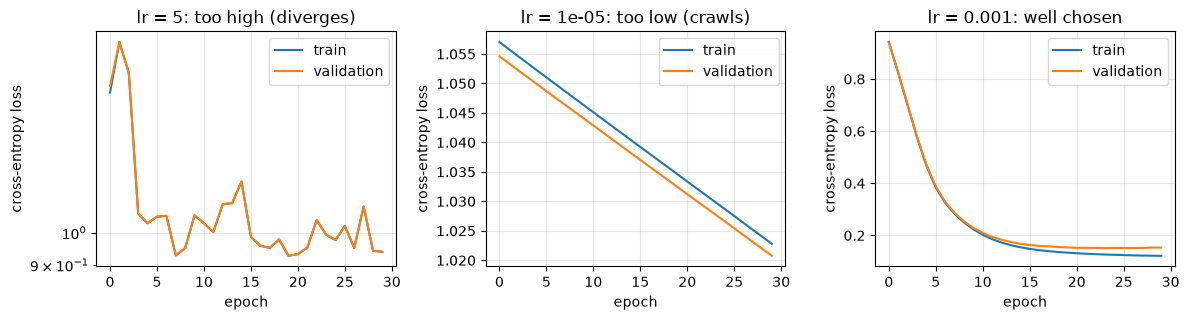

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.3), sharex=True)
for ax, (lr, label) in zip(axes, [(5.0, "too high (diverges)"),
                                  (1e-5, "too low (crawls)"),
                                  (1e-3, "well chosen")]):
    torch.manual_seed(8)
    model = MLP(width=32, depth=2)
    hist = train_model(model, data, epochs=30, lr=lr, optimizer="sgd"
                       if lr == 5.0 else "adam", seed=8)
    plot_history(hist, ax=ax, title=f"lr = {lr:g}: {label}", logy=(lr == 5.0))
plt.tight_layout()

Tres firmas a memorizar:

* **Demasiado alta**: la pérdida oscila o explota; cada paso se pasa del valle. (Con corridas inestables la pérdida puede llegar a `inf` o `NaN`; el eje logarítmico hace legible la explosión.)
* **Demasiado baja**: ambas curvas bajan arrastrándose por una línea casi recta y el entrenamiento «funciona» pero necesitaría cientos de épocas.
* **Bien elegida**: caída temprana rápida y luego un aplanamiento suave.

En caso de duda, barra primero la tasa de aprendizaje en potencias de 10. Nada más de esta sección importa hasta que esto esté aproximadamente bien.

### 5.2 Tamaño de lote

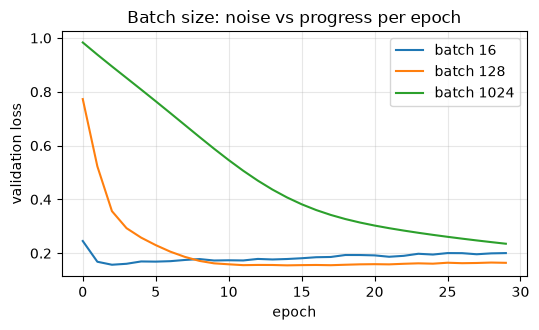

In [23]:
plt.figure(figsize=(5.5, 3.4))
for bs in [16, 128, 1024]:
    torch.manual_seed(9)
    model = MLP(width=32, depth=2)
    hist = train_model(model, data, epochs=30, batch_size=bs, seed=9)
    plt.plot(hist["val_loss"], label=f"batch {bs}")
plt.xlabel("epoch"); plt.ylabel("validation loss")
plt.legend(); plt.grid(alpha=0.3)
plt.title("Batch size: noise vs progress per epoch")
plt.tight_layout()

Los lotes pequeños dan muchos pasos ruidosos por época: progreso inicial rápido y un efecto regularizador leve, al precio de la agitación. Los lotes grandes dan pocos pasos suaves: cada época hace menos, así que con un presupuesto fijo de épocas la curva se rezaga, y los lotes muy grandes a menudo generalizan un poco peor. El tamaño de lote también fija el uso de memoria, que es lo que suele decidirlo en hardware real. La práctica común: el lote más grande que quepa cómodamente en memoria, con la tasa de aprendizaje reajustada cuando el lote cambia.

### 5.3 Sobreajuste en vivo, y parada temprana

Para forzar el sobreajuste le damos a un modelo grande un conjunto de entrenamiento pequeño y ruidoso y lo dejamos correr largo.

val loss at best epoch 15: 0.393
val loss at final epoch:  1.561


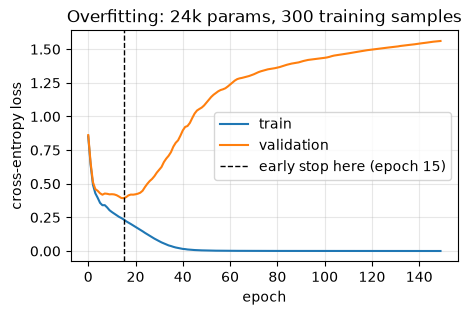

In [24]:
small_noisy = make_data(n_train=400, label_noise=0.10, seed=10)
torch.manual_seed(10)
big_model = MLP(width=256, depth=3)
hist_over = train_model(big_model, small_noisy, epochs=150, seed=10)

best_epoch = int(np.argmin(hist_over["val_loss"]))
ax = plot_history(hist_over, title="Overfitting: 24k params, 300 training samples")
ax.axvline(best_epoch, color="k", ls="--", lw=1,
           label=f"early stop here (epoch {best_epoch})")
ax.legend()
print(f"val loss at best epoch {best_epoch}: {hist_over['val_loss'][best_epoch]:.3f}")
print(f"val loss at final epoch:  {hist_over['val_loss'][-1]:.3f}")

La firma de libro de texto: la pérdida de entrenamiento cae hacia cero mientras la de validación toca fondo y sube. La **parada temprana** (*early stopping*) regulariza simplemente quedándose con el modelo de la época donde la pérdida de validación fue más baja. La implementación estándar lleva un contador de paciencia:

```python
best_val, patience, wait = float("inf"), 20, 0
for epoch in range(max_epochs):
    train_one_epoch(...)
    val = validation_loss(...)
    if val < best_val:
        best_val, wait = val, 0
        torch.save(model.state_dict(), "best.pt")   # checkpoint the best model
    else:
        wait += 1
        if wait > patience:
            break                                    # stop; reload best.pt
```

El cuaderno 4.2 cubre la mitad de este patrón que corresponde a los *checkpoints*.

### 5.4 Planificadores de la tasa de aprendizaje

Un programa (*schedule*) empieza con una tasa de aprendizaje grande para progresar rápido y la encoge para un final preciso — un compromiso entre los paneles «demasiado alta» y «demasiado baja» de la sección 5.1.

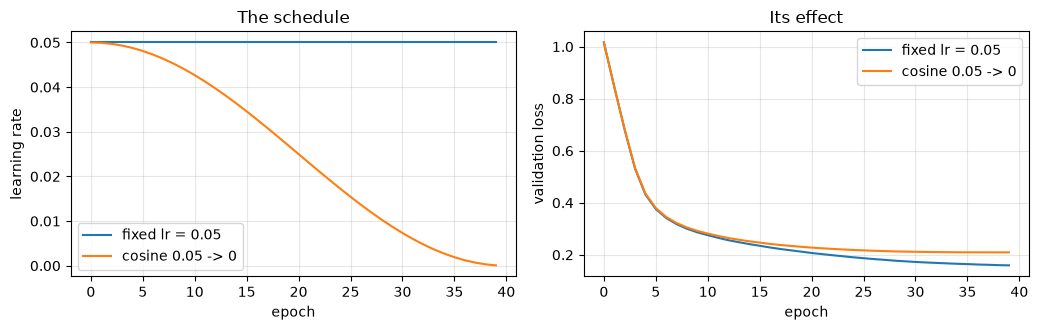

In [25]:
fig, ax = plt.subplots(1, 2, figsize=(10.5, 3.4))
runs = {
    "fixed lr = 0.05": dict(lr=0.05, scheduler=None),
    "cosine 0.05 -> 0": dict(lr=0.05,
        scheduler=lambda opt: torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=40)),
}
for label, kw in runs.items():
    torch.manual_seed(11)
    model = MLP(width=32, depth=2)
    hist = train_model(model, data, epochs=40, optimizer="sgd", seed=11, **kw)
    ax[0].plot(hist["lr"], label=label)
    ax[1].plot(hist["val_loss"], label=label)
ax[0].set_xlabel("epoch"); ax[0].set_ylabel("learning rate")
ax[0].set_title("The schedule"); ax[0].legend(); ax[0].grid(alpha=0.3)
ax[1].set_xlabel("epoch"); ax[1].set_ylabel("validation loss")
ax[1].set_title("Its effect"); ax[1].legend(); ax[1].grid(alpha=0.3)
plt.tight_layout()

`StepLR` (bajar la tasa por un factor cada $k$ épocas) y el recocido coseno (*cosine annealing*) son los dos programas que encontrará más a menudo. En un problema así de pequeño la ganancia es modesta; en modelos grandes, los planificadores son práctica estándar.

### 5.5 Ejercicio: diagnostique seis entrenamientos rotos

Abajo hay curvas de aprendizaje de seis corridas de entrenamiento, cada una rota de una manera distinta (o sospechosa de una manera distinta). Las patologías, en orden barajado: tasa de aprendizaje demasiado alta, tasa de aprendizaje demasiado baja, sobreajuste, subajuste (capacidad insuficiente), ruido fuerte en las etiquetas y fuga de datos hacia el conjunto de validación.

Diagnostique cada corrida a partir de sus curvas **antes** de leer el código de generación arriba de la figura o de abrir la solución.

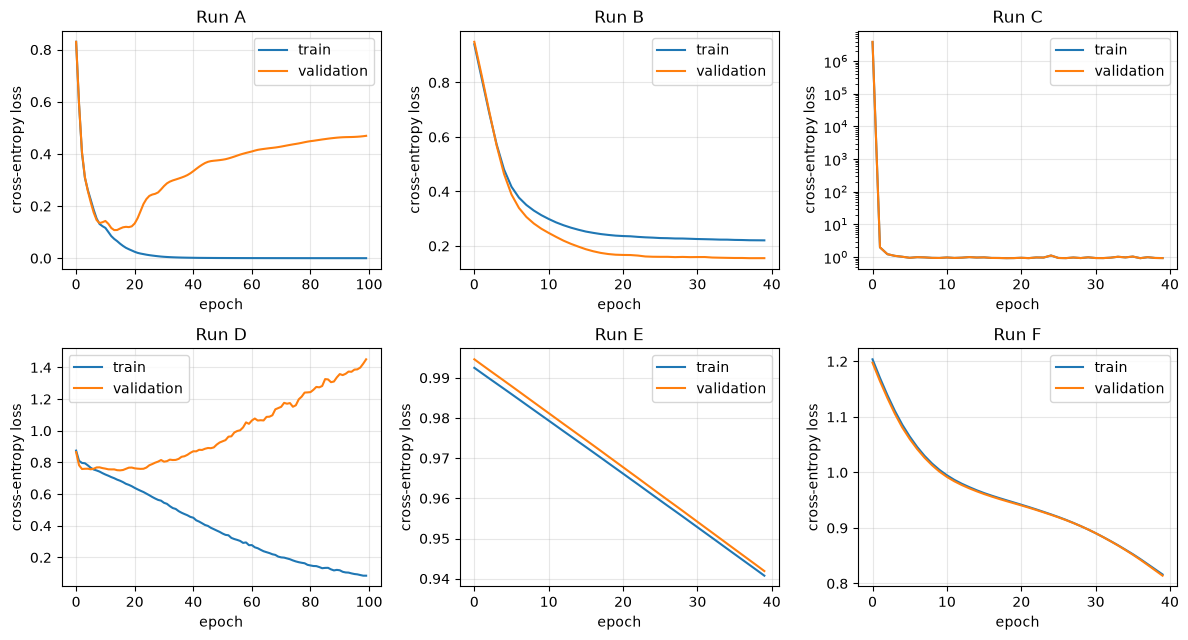

In [26]:
def make_broken_runs():
    '''Six rigged training runs. Diagnose from the curves before reading this.'''
    runs = {}
    d = make_data(seed=20)
    torch.manual_seed(20)
    runs["high_lr"] = train_model(MLP(32, 2), d, epochs=40, lr=5.0,
                                  optimizer="sgd", seed=20)
    torch.manual_seed(21)
    runs["low_lr"] = train_model(MLP(32, 2), d, epochs=40, lr=1e-5, seed=21)
    torch.manual_seed(22)
    runs["overfit"] = train_model(MLP(256, 3), make_data(n_train=400, seed=22),
                                  epochs=100, seed=22)
    torch.manual_seed(23)
    runs["underfit"] = train_model(MLP(1, 1), d, epochs=40, seed=23)   # width-1 bottleneck
    torch.manual_seed(24)
    runs["label_noise"] = train_model(MLP(256, 2),
                                      make_data(n_train=800, label_noise=0.35, seed=24),
                                      epochs=100, seed=24)
    # leakage-style pathology: training inputs get heavy augmentation noise,
    # validation stays pristine -> validation beats training throughout
    d_leak = list(make_data(seed=25))
    rng = np.random.default_rng(25)
    d_leak[0] = d_leak[0] + torch.as_tensor(
        rng.normal(0, 0.8, d_leak[0].shape), dtype=torch.float32)
    torch.manual_seed(25)
    runs["leakage"] = train_model(MLP(32, 2), tuple(d_leak), epochs=40, seed=25)
    return runs

broken = make_broken_runs()
display_order = ["overfit", "leakage", "high_lr", "label_noise", "low_lr", "underfit"]
letters = "ABCDEF"

fig, axes = plt.subplots(2, 3, figsize=(12, 6.5))
for ax, letter, key in zip(axes.ravel(), letters, display_order):
    plot_history(broken[key], ax=ax, title=f"Run {letter}",
                 logy=(max(broken[key]["train_loss"]) > 10))
plt.tight_layout()

Para cada corrida, anote: la patología, la evidencia en las curvas y el arreglo que probaría primero.

```{admonition} Solución
:class: dropdown

**Corrida A — sobreajuste.** La pérdida de entrenamiento cae hacia cero mientras la de validación toca fondo temprano y sube sostenidamente. Un modelo de 24k parámetros vio solo 300 muestras de entrenamiento. Arreglo: más datos, un modelo más pequeño, regularización o parada temprana en el mínimo de validación.

**Corrida B — fuga de datos (o aumento solo en entrenamiento).** La pérdida de validación queda *por debajo* de la de entrenamiento durante toda la corrida. Los datos de validación genuinos nunca son sistemáticamente más fáciles que los de entrenamiento; cuando la validación gana, sospeche que muestras de validación se filtraron al entrenamiento, que la división duplicó muestras casi idénticas a ambos lados de la frontera, o que el ruido/aumento se aplicó solo a las entradas de entrenamiento (la causa real aquí). Arreglo: audite la división antes de creerle a los números.

**Corrida C — tasa de aprendizaje demasiado alta.** La pérdida explota en unas pocas épocas (note el eje logarítmico) en lugar de disminuir. Los pasos se pasan del mínimo y divergen. Arreglo: baje la tasa de aprendizaje 10x-100x y vuelva a correr.

**Corrida D — ruido fuerte en las etiquetas.** La pérdida de entrenamiento sigue hundiéndose mientras el modelo sobredimensionado memoriza etiquetas volteadas, mientras que la de validación alcanza rápido un piso y se queda ahí — se estanca en lugar de subir con fuerza, y la exactitud de validación queda topada muy por debajo de lo que las características permiten. Distinguirlo del sobreajuste requiere cuidado: con ruido en las etiquetas, ninguna cantidad de regularización sube el techo de validación. Arreglo: audite y limpie las etiquetas (sección 3.1).

**Corrida E — tasa de aprendizaje demasiado baja.** Ambas curvas descienden por una línea tendida, casi recta, y siguen lejos de converger después de 40 épocas. No hay nada mal salvo la paciencia. Arreglo: suba la tasa de aprendizaje 10x-100x.

**Corrida F — subajuste.** Ambas curvas se estancan casi de inmediato en una pérdida alta con una brecha entrenamiento-validación diminuta. La red de ancho 1 no puede representar las fronteras de clase. Arreglo: aumente la capacidad (ancho/profundidad) o construya mejores características.
```

### 5.6 Búsqueda de hiperparámetros con Optuna

Después de los barridos manuales, la versión sistemática. [Optuna](https://optuna.org/) muestrea combinaciones de hiperparámetros, observa el puntaje de validación de cada ensayo y concentra la búsqueda donde los puntajes son buenos. Veinte ensayos en nuestra tarea pequeña toman menos de un minuto.

best validation accuracy: 0.928
best hyperparameters: {'lr': 0.024973286104060587, 'width': 32, 'dropout': 0.0716766437045232, 'weight_decay': 0.0060072494759062}


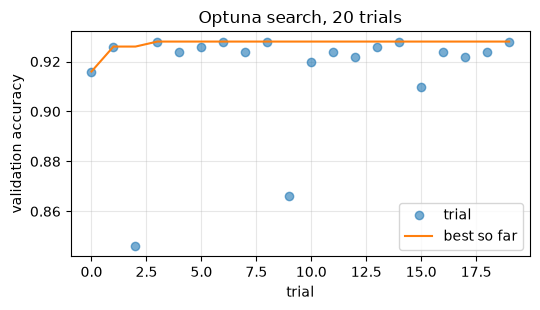

In [27]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

data_opt = make_data(n_train=2000, seed=30)

def objective(trial):
    lr = trial.suggest_float("lr", 1e-4, 1e-1, log=True)
    width = trial.suggest_categorical("width", [16, 32, 64, 128])
    dropout = trial.suggest_float("dropout", 0.0, 0.5)
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-2, log=True)
    torch.manual_seed(31)
    model = MLP(width=width, depth=2, dropout=dropout)
    hist = train_model(model, data_opt, epochs=12, lr=lr,
                       weight_decay=weight_decay, seed=31)
    return max(hist["val_acc"])

study = optuna.create_study(direction="maximize",
                            sampler=optuna.samplers.TPESampler(seed=0))
study.optimize(objective, n_trials=20)

print("best validation accuracy:", round(study.best_value, 3))
print("best hyperparameters:", study.best_params)

trial_vals = [t.value for t in study.trials]
plt.figure(figsize=(5.5, 3.2))
plt.plot(trial_vals, "o", alpha=0.6, label="trial")
plt.plot(np.maximum.accumulate(trial_vals), "-", label="best so far")
plt.xlabel("trial"); plt.ylabel("validation accuracy")
plt.legend(); plt.grid(alpha=0.3)
plt.title("Optuna search, 20 trials")
plt.tight_layout()

Busque los hiperparámetros que la sección 5 mostró que importan — la tasa de aprendizaje primero, luego la regularización y el ancho — sobre rangos que sus barridos manuales encontraron sensatos. Mantenga siempre el conjunto de prueba final fuera de la búsqueda: Optuna optimiza el puntaje de validación, y el conjunto de prueba se gasta una sola vez, al final.

### 5.7 Por qué la búsqueda de arquitecturas dejó de importar

Hace diez años, la búsqueda de arquitecturas neuronales — algoritmos que diseñan el cableado de la red automáticamente — era un frente de investigación activo. Se ha desvanecido en gran medida, por una razón simple: un puñado de arquitecturas canónicas (el MLP, la red convolucional, el *transformer*) más la escala ganaron. En dominio tras dominio, tomar una arquitectura estándar y gastar el cómputo en más datos, más parámetros y mejor entrenamiento venció al cableado a medida descubierto por búsqueda. Lo que queda del problema de búsqueda se mudó adonde usted acaba de practicarlo: los hiperparámetros (Optuna y sus parientes) y, sobre todo, el pilar de los datos. Este es también el consejo práctico para sus proyectos: elija la arquitectura canónica que corresponda a la estructura de sus datos, y luego gaste su esfuerzo en curaduría de datos y diagnósticos de entrenamiento.

## 6. Lista de verificación para entrenar un modelo de aprendizaje profundo

1. **Caracterice los datos** (capítulo 2): dimensionalidad, unidades, correlaciones, balance de clases.
2. **Aparte primero los datos de prueba.** Considere la causalidad y la independencia entre las muestras de prueba y de entrenamiento: las divisiones aleatorias filtran cuando las muestras están correlacionadas en el tiempo o el espacio.
3. **Cure los datos de entrenamiento** (Pilar 1): audite las etiquetas, cuantifique el ruido de medición, revise los conteos por clase y diversifique con aumento de datos donde las transformaciones físicas tengan sentido.
4. **Diseñe la red** (Pilar 2): empareje la familia de arquitectura con la estructura de los datos, empiece pequeño e incluya siempre el modelo de referencia lineal o de aprendizaje automático clásico.
5. **Defina la pérdida** apropiada para la tarea y los objetivos del dominio (sección 2), consultando la [documentación de funciones de pérdida de PyTorch](https://pytorch.org/docs/stable/nn.html#loss-functions) y las [métricas de scikit-learn](https://scikit-learn.org/stable/modules/model_evaluation.html).
6. **Elija el optimizador y la estrategia de entrenamiento** (Pilar 3): Adam por defecto, la tasa de aprendizaje barrida en potencias de diez, el lote más grande que quepa con comodidad, un planificador para corridas largas.
7. **Entrene con los diagnósticos encendidos**: registre las curvas de entrenamiento y validación en cada corrida, guarde un *checkpoint* del mejor modelo de validación, detenga temprano cuando la validación se estanque.
8. **Evalúe con honestidad**: métricas por clase, el conjunto de prueba intocado una sola vez, una estimación de incertidumbre (un ensamble profundo si puede costear cinco corridas, *MC dropout* si no), una verificación de calibración sobre cualquier probabilidad que reporte (sección 4.4) y una declaración de los rangos de entrenamiento fuera de los cuales ninguno de los números aplica (sección 4.6).

## 7. Resumen

Usted tiene ahora un vocabulario de diagnóstico atado a curvas que generó usted mismo: lo que cuestan el ruido en las etiquetas — aleatorio y estructurado —, el desbalance de clases y el ruido de sensores — uniforme y heterocedástico — (Pilar 1); cómo se comportan el ancho, la profundidad, los modelos de referencia, los ensambles y el *MC dropout*, en qué difiere la calibración de la discriminación y qué pasa fuera de rango (Pilar 2); y cómo se ven la tasa de aprendizaje, el tamaño de lote, el sobreajuste, la parada temprana y los planificadores en las curvas de aprendizaje (Pilar 3). Las seis corridas rotas de la sección 5.5 son el examen que los proyectos reales seguirán administrando.

Aplique este laboratorio a su propio proyecto: para el hito del proyecto final reutilizará los patrones de barrido sobre sus arquitecturas, llevará un apéndice de diagnósticos con al menos una corrida fallida y correrá o bien el análisis de ensamble profundo de la sección 4.4 o el experimento de ajuste fino del cuaderno 4.6.